In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Better plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
df  = pd.read_csv("/content/cleaned_data.csv")

In [3]:
df['date'] = pd.to_datetime(df['date'])

In [4]:
df.head(4)

,date,city,temperature_c,humidity_percent,electricity_units_kwh,household_size,income_level,power_outage_hours
0,2022-01-01,3,26.9,88,26.65,3,1,3.32
1,2022-01-02,4,31.4,85,25.32,3,0,1.26
2,2022-01-03,0,37.5,51,23.40,7,1,2.51
3,2022-01-04,4,22.8,65,20.51,4,0,2.47


In [5]:
df.set_index('date', inplace=True)

In [6]:
df.head(4)

,city,temperature_c,humidity_percent,electricity_units_kwh,household_size,income_level,power_outage_hours
date,,,,,,,
2022-01-01,3,26.9,88,26.65,3,1,3.32
2022-01-02,4,31.4,85,25.32,3,0,1.26
2022-01-03,0,37.5,51,23.40,7,1,2.51
2022-01-04,4,22.8,65,20.51,4,0,2.47


In [7]:
print(df.index)

DatetimeIndex(['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04',
               '2022-01-05', '2022-01-06', '2022-01-07', '2022-01-08',
               '2022-01-09', '2022-01-10',
               ...
               '2026-01-30', '2026-01-31', '2026-02-01', '2026-02-02',
               '2026-02-03', '2026-02-04', '2026-02-05', '2026-02-06',
               '2026-02-07', '2026-02-08'],
              dtype='datetime64[ns]', name='date', length=1500, freq=None)


In [8]:
# create the new features from the data like the year, month , ....
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day

In [9]:
df.sample(5)

,city,temperature_c,humidity_percent,electricity_units_kwh,household_size,income_level,power_outage_hours,year,month,day
date,,,,,,,,,,
2025-05-14,4,24.2,55,12.41,8,2,4.06,2025,5,14
2024-01-03,3,34.1,59,25.93,8,2,2.66,2024,1,3
2023-08-17,2,28.6,72,24.03,8,2,1.73,2023,8,17
2025-06-27,3,33.2,35,18.64,8,1,1.92,2025,6,27
2024-11-13,0,30.6,75,23.25,6,1,0.81,2024,11,13


In [10]:
df['day_of_week'] = df.index.dayofweek
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)

In [11]:
df.sample(6)

,city,temperature_c,humidity_percent,electricity_units_kwh,household_size,income_level,power_outage_hours,year,month,day,day_of_week,is_weekend
date,,,,,,,,,,,,
2025-08-04,4,37.1,38,13.40,8,2,1.59,2025,8,4,0,0
2025-08-17,2,43.8,68,24.92,7,0,1.78,2025,8,17,6,1
2022-09-05,1,47.1,76,23.55,3,2,0.81,2022,9,5,0,0
2024-12-31,2,23.4,41,21.04,8,0,2.14,2024,12,31,1,0
2022-05-10,4,19.0,72,17.94,2,1,1.50,2022,5,10,1,0
2023-04-19,4,25.3,52,21.79,4,1,0.62,2023,4,19,2,0


In [12]:
# create the lag features
df['lag_1'] = df['electricity_units_kwh'].shift(1)
df['lag_7'] = df['electricity_units_kwh'].shift(7)
df['lag_30'] = df['electricity_units_kwh'].shift(30)

print(df['lag_1'])
print(df['lag_7'])
print(df['lag_30'])

date
2022-01-01      NaN
2022-01-02    26.65
2022-01-03    25.32
2022-01-04    23.40
2022-01-05    20.51
              ...  
2026-02-04    18.42
2026-02-05    20.20
2026-02-06    26.85
2026-02-07    18.49
2026-02-08    17.50
Name: lag_1, Length: 1500, dtype: float64
date
2022-01-01      NaN
2022-01-02      NaN
2022-01-03      NaN
2022-01-04      NaN
2022-01-05      NaN
              ...  
2026-02-04    26.75
2026-02-05    18.58
2026-02-06    27.11
2026-02-07    14.62
2026-02-08    30.71
Name: lag_7, Length: 1500, dtype: float64
date
2022-01-01      NaN
2022-01-02      NaN
2022-01-03      NaN
2022-01-04      NaN
2022-01-05      NaN
              ...  
2026-02-04    33.67
2026-02-05    11.07
2026-02-06    18.41
2026-02-07    24.22
2026-02-08    25.51
Name: lag_30, Length: 1500, dtype: float64


In [13]:
df['rolling_mean_7'] = (
    df['electricity_units_kwh']
    .rolling(7)
    .mean()
)

df['rolling_mean_30'] = (
    df['electricity_units_kwh']
    .rolling(30)
    .mean()
)

In [14]:
df['rolling_mean_7'].head(7)

,rolling_mean_7
date,
2022-01-01,NaN
2022-01-02,NaN
2022-01-03,NaN
2022-01-04,NaN
2022-01-05,NaN
2022-01-06,NaN
2022-01-07,22.588571


In [15]:
df['rolling_mean_30'].head(30)

,rolling_mean_30
date,
2022-01-01,NaN
2022-01-02,NaN
2022-01-03,NaN
2022-01-04,NaN
2022-01-05,NaN
2022-01-06,NaN
2022-01-07,NaN
2022-01-08,NaN
2022-01-09,NaN


In [16]:
print(df.isnull().sum())

city                      0
temperature_c             0
humidity_percent          0
electricity_units_kwh     0
household_size            0
income_level              0
power_outage_hours        0
year                      0
month                     0
day                       0
day_of_week               0
is_weekend                0
lag_1                     1
lag_7                     7
lag_30                   30
rolling_mean_7            6
rolling_mean_30          29
dtype: int64


In [17]:
df.head()

,city,temperature_c,humidity_percent,electricity_units_kwh,household_size,income_level,power_outage_hours,year,month,day,day_of_week,is_weekend,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
date,,,,,,,,,,,,,,,,,
2022-01-01,3,26.9,88,26.65,3,1,3.32,2022,1,1,5,1,NaN,NaN,NaN,NaN,NaN
2022-01-02,4,31.4,85,25.32,3,0,1.26,2022,1,2,6,1,26.65,NaN,NaN,NaN,NaN
2022-01-03,0,37.5,51,23.40,7,1,2.51,2022,1,3,0,0,25.32,NaN,NaN,NaN,NaN
2022-01-04,4,22.8,65,20.51,4,0,2.47,2022,1,4,1,0,23.40,NaN,NaN,NaN,NaN
2022-01-05,4,30.9,63,29.20,7,2,0.32,2022,1,5,2,0,20.51,NaN,NaN,NaN,NaN


In [18]:
df = df.dropna()

In [19]:
print(df.isnull().sum())

city                     0
temperature_c            0
humidity_percent         0
electricity_units_kwh    0
household_size           0
income_level             0
power_outage_hours       0
year                     0
month                    0
day                      0
day_of_week              0
is_weekend               0
lag_1                    0
lag_7                    0
lag_30                   0
rolling_mean_7           0
rolling_mean_30          0
dtype: int64


In [20]:
df.head()

,city,temperature_c,humidity_percent,electricity_units_kwh,household_size,income_level,power_outage_hours,year,month,day,day_of_week,is_weekend,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
date,,,,,,,,,,,,,,,,,
2022-01-31,0,29.7,46,14.24,5,1,1.30,2022,1,31,0,0,24.17,25.48,26.65,23.034286,22.247333
2022-02-01,3,31.7,39,25.43,3,2,1.22,2022,2,1,1,0,14.24,17.76,25.32,24.130000,22.251000
2022-02-02,3,28.3,79,24.70,4,2,2.02,2022,2,2,2,0,25.43,27.13,23.40,23.782857,22.294333
2022-02-03,1,32.5,56,10.78,8,0,1.04,2022,2,3,3,0,24.70,31.90,20.51,20.765714,21.970000
2022-02-04,0,21.2,83,15.03,2,2,0.48,2022,2,4,4,0,10.78,28.42,29.20,18.852857,21.497667


In [21]:
df.reset_index(inplace=True)

df.to_csv("feature_engineered_data.csv", index=False)

###Electricity Consumption by Day of the Week

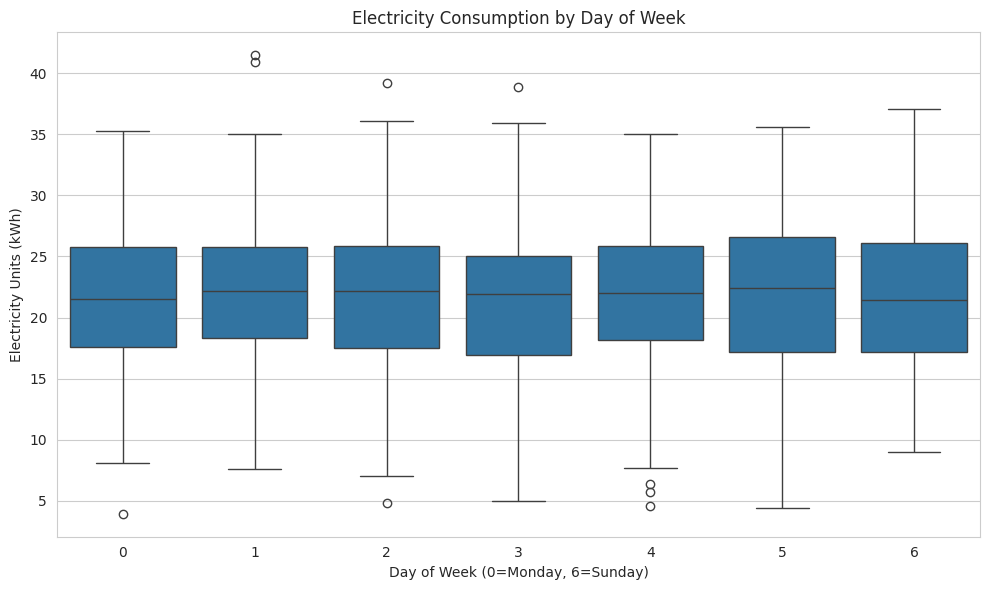

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='day_of_week', y='electricity_units_kwh', data=df)
plt.title('Electricity Consumption by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Electricity Units (kWh)')
plt.tight_layout()
plt.show()